# Dementia Progression Forecasting via Longitudinal Cognitive Trajectory Modelling

## 0. Setup: Imports and Reproducibility

In [1]:
# =========================================================
# 0) SETUP — reproducibility + imports
# =========================================================
import os, random, math, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Setup complete. Libraries imported and random seeds set.")

Setup complete. Libraries imported and random seeds set.


## 1. Data Loading

In [2]:
url = 'https://raw.githubusercontent.com/multivacplatform/multivac-dl/master/data/mri-and-alzheimers/oasis_longitudinal.csv'
df = pd.read_csv(url)
print("Loaded from GitHub. Raw shape:", df.shape)
df.head()

Loaded from GitHub. Raw shape: (373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


## 2. Exploratory Data Analysis (EDA)

Before modelling we examine the dataset to understand its structure,
class distribution, missing values, and the relationship between clinical features.

In [3]:
# =========================================================
# 2) EXPLORATORY DATA ANALYSIS
# =========================================================
df_clean = df.dropna(subset=['MMSE']).copy()
df_clean.columns = [c.strip() for c in df_clean.columns]

print('='*50)
print('OASIS-2 Dataset Summary')
print('='*50)
print(f'Subjects       : {df_clean["Subject ID"].nunique()}')
print(f'Visit records  : {len(df_clean)}')
print(f'Features       : {df_clean.shape[1]}')
print(f'\nGroup distribution:')
print(df_clean.groupby("Subject ID")["Group"].first().value_counts().to_string())
print(f'\nMissing values:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].to_string())

# Visits per subject
vps = df_clean.groupby('Subject ID')['Visit'].count()
print(f'\nVisits per subject:')
print(f'  Min: {vps.min()}  Max: {vps.max()}  Mean: {vps.mean():.1f}')

OASIS-2 Dataset Summary
Subjects       : 150
Visit records  : 371
Features       : 15

Group distribution:
Group
Nondemented    72
Demented       64
Converted      14

Missing values:
SES    17

Visits per subject:
  Min: 1  Max: 5  Mean: 2.5


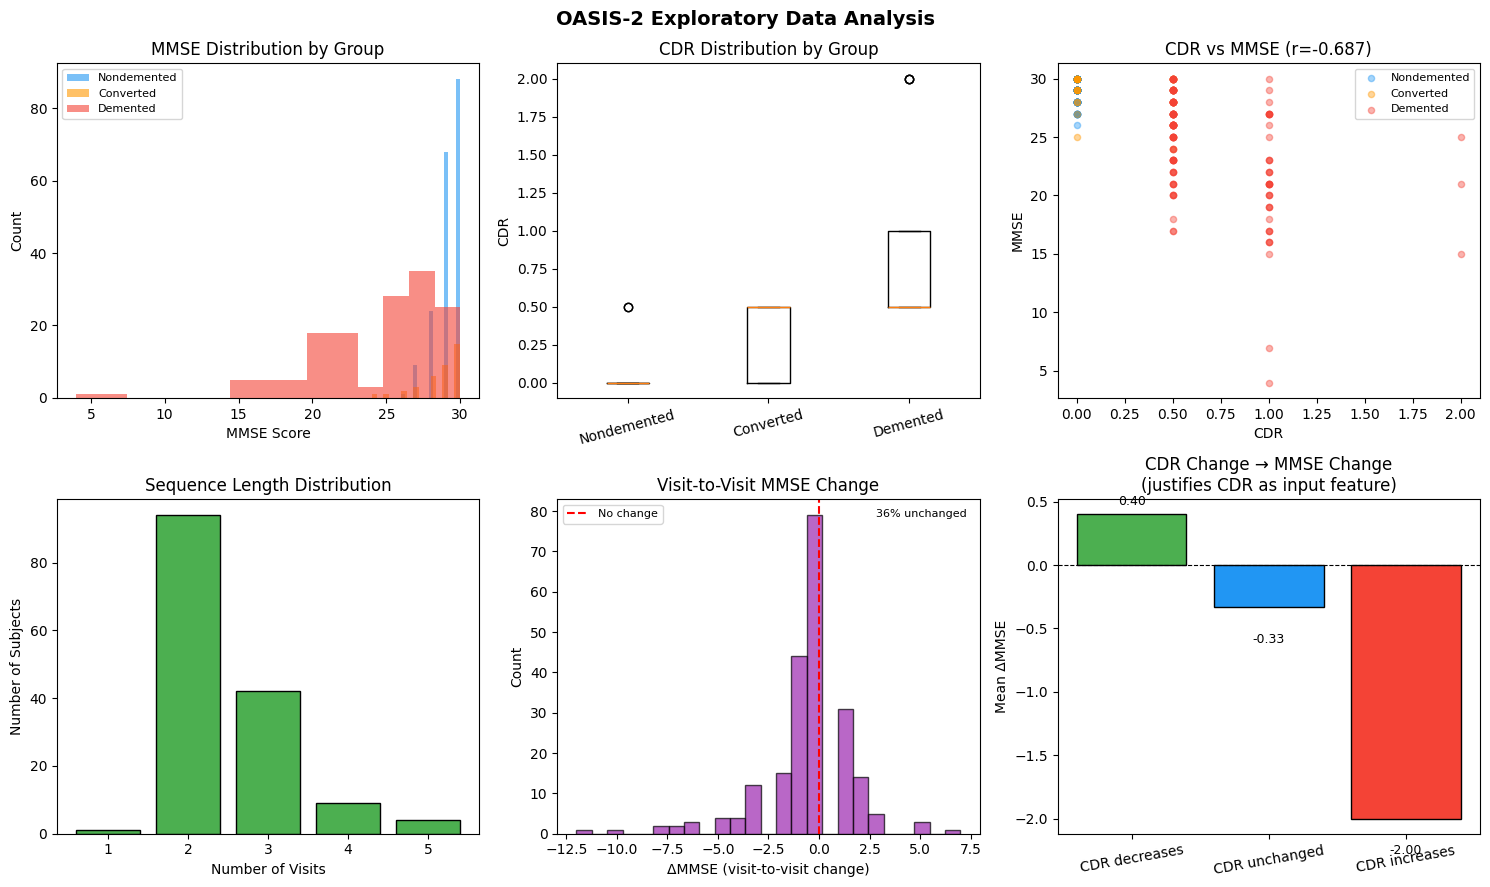

EDA saved to eda_oasis2.png


In [ ]:
# ── EDA: Visual exploration ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('OASIS-2 Exploratory Data Analysis', fontsize=14, fontweight='bold')

# 1. MMSE distribution by Group
ax = axes[0, 0]
for group, colour in [('Nondemented','#2196F3'), ('Converted','#FF9800'), ('Demented','#F44336')]:
    mask = df_clean['Group'] == group
    ax.hist(df_clean.loc[mask, 'MMSE'], bins=15, alpha=0.6, color=colour, label=group)
ax.set_xlabel('MMSE Score')
ax.set_ylabel('Count')
ax.set_title('MMSE Distribution by Group')
ax.legend(fontsize=8)

# 2. CDR distribution by Group
ax = axes[0, 1]
order = ['Nondemented', 'Converted', 'Demented']
cdr_by_group = [df_clean.loc[df_clean['Group']==g, 'CDR'].values for g in order]
ax.boxplot(cdr_by_group, labels=order)
ax.set_ylabel('CDR')
ax.set_title('CDR Distribution by Group')
ax.tick_params(axis='x', rotation=15)

# 3. CDR vs MMSE scatter
ax = axes[0, 2]
colour_map = {'Nondemented': '#2196F3', 'Converted': '#FF9800', 'Demented': '#F44336'}
for group, colour in colour_map.items():
    mask = df_clean['Group'] == group
    ax.scatter(df_clean.loc[mask, 'CDR'], df_clean.loc[mask, 'MMSE'],
               alpha=0.4, s=20, color=colour, label=group)
ax.set_xlabel('CDR')
ax.set_ylabel('MMSE')
ax.set_title(f"CDR vs MMSE (r={df_clean[['CDR','MMSE']].corr().iloc[0,1]:.3f})")
ax.legend(fontsize=8)

# 4. Sequence length distribution
ax = axes[1, 0]
visit_counts = df_clean.groupby('Subject ID')['Visit'].count()
ax.bar(visit_counts.value_counts().sort_index().index,
       visit_counts.value_counts().sort_index().values,
       color='#4CAF50', edgecolor='black')
ax.set_xlabel('Number of Visits')
ax.set_ylabel('Number of Subjects')
ax.set_title('Sequence Length Distribution')

# 5. MMSE change distribution (next-step targets)
ax = axes[1, 1]
mmse_changes = []
for sid, g in df_clean.groupby('Subject ID'):
    g = g.sort_values('Visit')
    if len(g) >= 2:
        mmse_changes.extend(g['MMSE'].diff().dropna().tolist())
ax.hist(mmse_changes, bins=25, color='#9C27B0', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No change')
ax.set_xlabel('ΔMMSE (visit-to-visit change)')
ax.set_ylabel('Count')
ax.set_title('Visit-to-Visit MMSE Change')
ax.legend(fontsize=8)
same_pct = sum(1 for x in mmse_changes if x == 0) / len(mmse_changes) * 100
print(f"Proportion of zero-change consecutive pairs: {same_pct:.1f}%")
ax.text(0.97, 0.97, f'{same_pct:.0f}% unchanged', transform=ax.transAxes,
        ha='right', va='top', fontsize=8)

# 6. CDR change predicts MMSE change
ax = axes[1, 2]
cdr_bins = {'CDR decreases': [], 'CDR unchanged': [], 'CDR increases': []}
for sid, g in df_clean.groupby('Subject ID'):
    g = g.sort_values('Visit')
    if len(g) >= 2:
        for i in range(1, len(g)):
            dc = g['CDR'].iloc[i] - g['CDR'].iloc[i-1]
            dm = g['MMSE'].iloc[i] - g['MMSE'].iloc[i-1]
            if dc < 0:   cdr_bins['CDR decreases'].append(dm)
            elif dc == 0: cdr_bins['CDR unchanged'].append(dm)
            else:         cdr_bins['CDR increases'].append(dm)
labels = list(cdr_bins.keys())
means = [np.mean(v) for v in cdr_bins.values()]
colours = ['#4CAF50', '#2196F3', '#F44336']
bars = ax.bar(labels, means, color=colours, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean ΔMMSE')
ax.set_title('CDR Change → MMSE Change\n(justifies CDR as input feature)')
ax.tick_params(axis='x', rotation=10)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.05 if mean >= 0 else mean - 0.2,
            f'{mean:.2f}', ha='center', va='bottom' if mean >= 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('eda_oasis2.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA saved to eda_oasis2.png')

## 3. Feature Engineering and Column Configuration



In [ ]:
# =========================================================
# 3) COLUMN CONFIGURATION
# =========================================================
SUBJECT_COL = "Subject ID"
VISIT_COL   = "Visit"
TARGET_COL  = "MMSE"

CAT_COLS = ["M/F", "Hand"]   # binary categoricals

# All numeric covariates measured at each visit
# CDR is included because:
#   (a) it is measured concurrently with MMSE at each visit
#   (b) EDA shows it strongly predicts MMSE trajectory
#   (c) using CDR(t) to forecast MMSE(t+1) is not data leakage
NUM_COLS = ["MR Delay", "Age", "EDUC", "SES", "CDR", "eTIV", "nWBV", "ASF"]

# Autoregressive + clinical input features
FEATURE_NUM_COLS = [TARGET_COL] + NUM_COLS

print("Input feature set:")
print(f"  Numeric  : {FEATURE_NUM_COLS}")
print(f"  Categorical: {CAT_COLS}")
print(f"  Target   : {TARGET_COL} at visit t+1")

Input feature set:
  Numeric  : ['MMSE', 'MR Delay', 'Age', 'EDUC', 'SES', 'CDR', 'eTIV', 'nWBV', 'ASF']
  Categorical: ['M/F', 'Hand']
  Target   : MMSE at visit t+1


## 4. Data Preprocessing

In [ ]:
# =========================================================
# 4) CLEAN + SORT
# =========================================================
df = df.copy()
df.columns = [c.strip() for c in df.columns]
df = df.sort_values([SUBJECT_COL, VISIT_COL]).reset_index(drop=True)

# Ensure visit number is integer, drop rows with missing MMSE or Visit
df[VISIT_COL] = pd.to_numeric(df[VISIT_COL], errors='coerce')
df = df.dropna(subset=[VISIT_COL, TARGET_COL]).copy()
df[VISIT_COL] = df[VISIT_COL].astype(int)

print("Clean shape:", df.shape)
df[[SUBJECT_COL, VISIT_COL, TARGET_COL, 'CDR', 'Group']].head(10)

Clean shape: (371, 15)


,Subject ID,Visit,MMSE,CDR,Group
0,OAS2_0001,1,27.0,0.0,Nondemented
1,OAS2_0001,2,30.0,0.0,Nondemented
2,OAS2_0002,1,23.0,0.5,Demented
3,OAS2_0002,2,28.0,0.5,Demented
4,OAS2_0002,3,22.0,0.5,Demented
5,OAS2_0004,1,28.0,0.0,Nondemented
6,OAS2_0004,2,27.0,0.0,Nondemented
7,OAS2_0005,1,28.0,0.0,Nondemented
8,OAS2_0005,2,29.0,0.5,Nondemented
9,OAS2_0005,3,30.0,0.0,Nondemented


## 5. Patient-Wise Data Split

We perform a **patient-wise** (group-aware) split so that all visits of a given
subject stay in the same partition. This prevents **temporal leakage** — the model
cannot see future visits of the same patient during training.

Target proportions: ~70% train / 15% validation / 15% test (by number of subjects).

In [ ]:
# =========================================================
# 5) PATIENT-WISE SPLIT (prevents leakage across visits)
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(gss.split(df, groups=df[SUBJECT_COL]))

df_trainval = df.iloc[trainval_idx].copy()
df_test     = df.iloc[test_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)  # ~15% of full for val
train_idx, val_idx = next(gss2.split(df_trainval, groups=df_trainval[SUBJECT_COL]))

df_train = df_trainval.iloc[train_idx].copy()
df_val   = df_trainval.iloc[val_idx].copy()

n_tr = df_train[SUBJECT_COL].nunique()
n_va = df_val[SUBJECT_COL].nunique()
n_te = df_test[SUBJECT_COL].nunique()
print(f"Subjects  → train: {n_tr} | val: {n_va} | test: {n_te}")
print(f"Records   → train: {len(df_train)} | val: {len(df_val)} | test: {len(df_test)}")

# Verify no subject overlap across splits
assert set(df_train[SUBJECT_COL]) & set(df_val[SUBJECT_COL]) == set()
assert set(df_train[SUBJECT_COL]) & set(df_test[SUBJECT_COL]) == set()
assert set(df_val[SUBJECT_COL])   & set(df_test[SUBJECT_COL]) == set()
print("✓ No subject overlap between splits")

Subjects  → train: 104 | val: 23 | test: 23
Records   → train: 252 | val: 59 | test: 60
✓ No subject overlap between splits


In [ ]:
# =========================================================
# 6) IMPUTE NUMERIC MISSING VALUES (train medians only)
# Fit imputation statistics on TRAINING set only to avoid data leakage.
# =========================================================
train_medians = df_train[NUM_COLS].median(numeric_only=True)
print("Training medians used for imputation:")
print(train_medians.to_string())

for split_df in [df_train, df_val, df_test]:
    for c in NUM_COLS:
        split_df[c] = split_df[c].fillna(train_medians.get(c, split_df[c].median()))

print("\n✓ Missing value imputation complete")

Training medians used for imputation:
MR Delay     538.5000
Age           76.0000
EDUC          14.0000
SES            2.0000
CDR            0.0000
eTIV        1474.5000
nWBV           0.7285
ASF            1.1900

✓ Missing value imputation complete


In [ ]:
# =========================================================
# 7) ONE-HOT ENCODE CATEGORICAL FEATURES
# Fit schema on training set; reindex val/test to same columns.
# =========================================================
def one_hot_fit_transform(train_df, other_dfs, cat_cols):
    train_enc = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    cols = train_enc.columns
    out = [train_enc]
    for d in other_dfs:
        enc = pd.get_dummies(d, columns=cat_cols, drop_first=False)
        enc = enc.reindex(columns=cols, fill_value=0)
        out.append(enc)
    return out

df_train_enc, df_val_enc, df_test_enc = one_hot_fit_transform(
    df_train, [df_val, df_test], CAT_COLS
)

# Build final per-timestep feature list: numeric + one-hot dummies
all_feature_cols = list(FEATURE_NUM_COLS)
for c in df_train_enc.columns:
    if any(c.startswith(f"{k}_") for k in CAT_COLS):
        all_feature_cols.append(c)

print(f"Total input features per timestep : {len(all_feature_cols)}")
print(f"Feature list: {all_feature_cols}")

Total input features per timestep : 12
Feature list: ['MMSE', 'MR Delay', 'Age', 'EDUC', 'SES', 'CDR', 'eTIV', 'nWBV', 'ASF', 'M/F_F', 'M/F_M', 'Hand_R']


## 6. Sequence Construction

We convert the longitudinal records into **many-to-one** forecasting examples.
For a patient with $N$ visits, we generate $N-1$ examples:

$$\text{Input: } (\mathbf{x}_1, \ldots, \mathbf{x}_t) \rightarrow \text{Target: } \text{MMSE}_{t+1}$$

Since sequences have different lengths (1–4 steps), we **zero-pad** to the maximum
length and use a **Masking layer** to ignore padded positions during forward/backward pass.

In [ ]:
# =========================================================
# 8) BUILD NEXT-STEP FORECASTING EXAMPLES (many-to-one)
# Input: visits 1..t  →  Target: absolute MMSE at visit t+1
# =========================================================
def make_nextstep_examples_abs(df_enc):
    """Build (variable-length sequence, next-MMSE) pairs."""
    X_list, y_list, sid_list = [], [], []
    for sid, g in df_enc.groupby(SUBJECT_COL):
        g = g.sort_values(VISIT_COL)
        if len(g) < 2:
            continue
        X   = g[all_feature_cols].to_numpy(dtype=np.float32)
        mmse = g[TARGET_COL].to_numpy(dtype=np.float32)
        for t in range(1, len(g)):
            X_list.append(X[:t, :])     # history up to visit t-1
            y_list.append(mmse[t])       # absolute MMSE at visit t
            sid_list.append(sid)
    return X_list, np.array(y_list, dtype=np.float32), np.array(sid_list)

X_tr_v, y_tr, sid_tr = make_nextstep_examples_abs(df_train_enc)
X_va_v, y_va, sid_va = make_nextstep_examples_abs(df_val_enc)
X_te_v, y_te, sid_te = make_nextstep_examples_abs(df_test_enc)

max_len = max([x.shape[0] for x in (X_tr_v + X_va_v + X_te_v)])
n_feat  = X_tr_v[0].shape[1]

def pad(X_list, max_len, n_feat):
    """Zero-pad variable-length sequences to fixed length."""
    Xp = np.zeros((len(X_list), max_len, n_feat), dtype=np.float32)
    m  = np.zeros((len(X_list), max_len), dtype=np.float32)
    for i, x in enumerate(X_list):
        L = x.shape[0]
        Xp[i, :L, :] = x
        m[i, :L] = 1.0
    return Xp, m

X_tr, m_tr = pad(X_tr_v, max_len, n_feat)
X_va, m_va = pad(X_va_v, max_len, n_feat)
X_te, m_te = pad(X_te_v, max_len, n_feat)

print(f"Forecasting examples → train: {X_tr.shape[0]} | val: {X_va.shape[0]} | test: {X_te.shape[0]}")
print(f"Max sequence length  : {max_len}")
print(f"Features per timestep: {n_feat}")

Forecasting examples → train: 148 | val: 36 | test: 37
Max sequence length  : 4
Features per timestep: 12


In [ ]:
# =========================================================
# 9) STANDARDISE FEATURES (fit only on training timesteps)
#
# CRITICAL: We scale ONLY real (non-padded) timesteps so padded
# positions remain exactly 0.0 — required for Masking(mask_value=0.0).
# Scaling the full array including padded zeros shifts those positions
# away from 0, silently breaking the masking layer.
# =========================================================
scaler = StandardScaler()
train_timesteps = X_tr[m_tr.astype(bool)].reshape(-1, n_feat)
scaler.fit(train_timesteps)

def scale_3d_masked(X, mask):
    """Scale real timesteps only; keep padded zeros at exactly 0."""
    X_scaled = np.zeros_like(X)
    for i in range(len(X)):
        L = int(mask[i].sum())
        if L > 0:
            X_scaled[i, :L, :] = scaler.transform(X[i, :L, :])
    return X_scaled

X_tr_s = scale_3d_masked(X_tr, m_tr)
X_va_s = scale_3d_masked(X_va, m_va)
X_te_s = scale_3d_masked(X_te, m_te)

# Sanity check: padded positions must remain exactly 0
assert np.all(X_tr_s[m_tr == 0] == 0.0), "Padded values not zero after scaling!"
print("✓ Masking-safe scaling verified: padded positions remain 0.0")

✓ Masking-safe scaling verified: padded positions remain 0.0


## 7. Baseline Models

Three baselines establish the minimum performance bar:


In [ ]:
# =========================================================
# 10) METRICS + BASELINES
# =========================================================
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

mmse_feat_idx = all_feature_cols.index(TARGET_COL)

def inverse_scale_feature(z, feature_index):
    return z * scaler.scale_[feature_index] + scaler.mean_[feature_index]

def extract_last_visit(X_scaled, mask):
    """Extract the last observed (non-padded) timestep per example."""
    last_idx = (mask.sum(axis=1) - 1).astype(int)
    return np.array([X_scaled[i, last_idx[i], :] for i in range(len(X_scaled))])

# Persistence: next_MMSE = last_observed_MMSE
last_idx = (m_te.sum(axis=1) - 1).astype(int)
yhat_persist_scaled = np.array([X_te_s[i, last_idx[i], mmse_feat_idx]
                                 for i in range(len(X_te_s))], dtype=np.float32)
yhat_persist = inverse_scale_feature(yhat_persist_scaled, mmse_feat_idx)

# Train-mean
yhat_mean = np.full_like(y_te, fill_value=float(np.mean(y_tr)), dtype=np.float32)

# Linear Regression (last-visit features → next MMSE)
X_tr_last = extract_last_visit(X_tr_s, m_tr)
X_va_last = extract_last_visit(X_va_s, m_va)
X_te_last = extract_last_visit(X_te_s, m_te)

lr_model = Ridge(alpha=1.0)
lr_model.fit(X_tr_last, y_tr)
yhat_lr = lr_model.predict(X_te_last)

print("=" * 55)
print("Absolute MMSE Forecasting — Baselines (Test Set)")
print("=" * 55)
for name, yhat_ in [
    ('Persistence  (last MMSE)', yhat_persist),
    ('Training-Mean             ', yhat_mean),
    ('Linear Regression         ', yhat_lr),
]:
    print(f"{name}  MAE={mean_absolute_error(y_te, yhat_):.4f}  "
          f"RMSE={rmse(y_te, yhat_):.4f}  R²={r2_score(y_te, yhat_):.4f}")

Absolute MMSE Forecasting — Baselines (Test Set)
Persistence  (last MMSE)  MAE=0.9459  RMSE=1.3656  R²=0.7160
Training-Mean               MAE=2.2310  RMSE=2.7946  R²=-0.1893
Linear Regression           MAE=1.2573  RMSE=1.6446  R²=0.5881


## 8. Recurrent Architecture Designs

All architectures share the same skeleton: `Input → Masking → RecurrentCell → Dense(32, relu) → Dense(1)`.


In [ ]:
# =========================================================
# 11) MODEL BUILDERS: RNN / LSTM / GRU / BiLSTM
# =========================================================
def build_model(cell_type, units=32, dropout=0.2, lr=1e-3):
    """
    Build a recurrent model for next-step MMSE forecasting.

    Architecture:
        Input(max_len, n_feat)
        → Masking(mask_value=0.0)   # ignores padded zeros
        → RecurrentCell(units)      # RNN / LSTM / GRU / Bidirectional-LSTM
        → Dense(32, relu)
        → Dense(1)  [linear output = predicted MMSE]
    """
    inp = tf.keras.Input(shape=(max_len, n_feat))
    x   = tf.keras.layers.Masking(mask_value=0.0)(inp)

    if cell_type == "RNN":
        x = tf.keras.layers.SimpleRNN(units, dropout=dropout)(x)
    elif cell_type == "LSTM":
        x = tf.keras.layers.LSTM(units, dropout=dropout)(x)
    elif cell_type == "GRU":
        x = tf.keras.layers.GRU(units, dropout=dropout)(x)
    elif cell_type == "BiLSTM":
        x = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(units, dropout=dropout))(x)
    else:
        raise ValueError(f"cell_type must be RNN/LSTM/GRU/BiLSTM, got {cell_type!r}")

    x   = tf.keras.layers.Dense(32, activation='relu')(x)
    out = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model


def train_eval(cell_type, units=32, dropout=0.2, batch=32, epochs=300, lr=1e-3):
    """Train a model, apply early stopping, and evaluate on the test set."""
    model = build_model(cell_type, units, dropout, lr=lr)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=30, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', patience=12, factor=0.5, min_lr=1e-5)
    ]
    history = model.fit(
        X_tr_s, y_tr,
        validation_data=(X_va_s, y_va),
        epochs=epochs,
        batch_size=batch,
        verbose=0,
        callbacks=callbacks
    )
    yhat = model.predict(X_te_s, batch_size=128, verbose=0).reshape(-1)
    res = {
        'Model':         cell_type,
        'Units':         units,
        'Dropout':       dropout,
        'Batch':         batch,
        'EpochsTrained': int(len(history.history['loss'])),
        'MAE':           float(mean_absolute_error(y_te, yhat)),
        'RMSE':          float(rmse(y_te, yhat)),
        'R2':            float(r2_score(y_te, yhat)),
        'BestValLoss':   float(min(history.history['val_loss'])),
    }
    return res, model, history, yhat

# Show one model summary for documentation
print("=== LSTM Architecture Summary ===")
build_model('LSTM').summary()

=== LSTM Architecture Summary ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4, 12)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 4, 12)     │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 4, 12)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 4)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      5,760 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Quick Architecture Comparison (Default Hyperparameters)

First we train all four architectures with a single default configuration
to get a quick read on their relative performance.

In [ ]:
# =========================================================
# 12) QUICK COMPARISON — all 4 architectures, single config
# =========================================================
quick_results  = []
quick_models   = {}
quick_histories = {}
quick_preds    = {}

for cell in ['RNN', 'LSTM', 'GRU', 'BiLSTM']:
    res, mdl, hist, yhat = train_eval(cell_type=cell, units=32, dropout=0.2)
    quick_results.append(res)
    quick_models[cell]    = mdl
    quick_histories[cell] = hist
    quick_preds[cell]     = yhat
    print(f"{cell:8s}  MAE={res['MAE']:.4f}  RMSE={res['RMSE']:.4f}  "
          f"R²={res['R2']:.4f}  epochs={res['EpochsTrained']}")

quick_df = pd.DataFrame(quick_results).sort_values('RMSE')
print("\nQuick comparison (sorted by RMSE):")
quick_df

RNN       MAE=2.0774  RMSE=2.8178  R²=-0.2091  epochs=165
LSTM      MAE=1.2388  RMSE=1.6773  R²=0.5716  epochs=227
GRU       MAE=1.1845  RMSE=1.5044  R²=0.6553  epochs=193
BiLSTM    MAE=1.4447  RMSE=1.9819  R²=0.4019  epochs=239

Quick comparison (sorted by RMSE):


,Model,Units,Dropout,Batch,EpochsTrained,MAE,RMSE,R2,BestValLoss
2,GRU,32,0.2,32,193,1.184492,1.504422,0.655346,5.011057
1,LSTM,32,0.2,32,227,1.238774,1.677267,0.571601,8.643186
3,BiLSTM,32,0.2,32,239,1.444664,1.981883,0.401864,7.083149
0,RNN,32,0.2,32,165,2.077357,2.817765,-0.209075,6.314317


## 10. Hyperparameter Sweep

We perform a grid search over:
- **Units**: 16, 32, 64
- **Dropout**: 0.0, 0.2, 0.4
- **Batch size**: 8, 16, 32

This gives $4 \times 3 \times 3 \times 3 = 108$ configurations.
**Model selection uses validation loss** (not test RMSE) to avoid test-set leakage.

In [ ]:
# =========================================================
# 13) HYPERPARAMETER SWEEP — 108 configs across 4 architectures
# Selection criterion: minimum BestValLoss (NOT test RMSE)
# =========================================================
sweep        = []
best_by_type = {}

architectures = ['RNN', 'LSTM', 'GRU', 'BiLSTM']
units_list    = [16, 32, 64]
dropout_list  = [0.0, 0.2, 0.4]
batch_list    = [8, 16, 32]
total = len(architectures) * len(units_list) * len(dropout_list) * len(batch_list)  # 108
run = 0

for cell in architectures:
    best_val_loss = float('inf')
    best_pack     = None
    print(f"{'='*60}")
    print(f"  Architecture: {cell}")
    print(f"{'='*60}")

    for units in units_list:
        for dropout in dropout_list:
            for batch in batch_list:
                run += 1
                print(f"  [{run:>3}/{total}] units={units}  dropout={dropout}  batch={batch:>2}",
                      end=' ... ', flush=True)

                res, mdl, hist, yhat = train_eval(
                    cell_type=cell, units=units, dropout=dropout, batch=batch)
                sweep.append(res)

                marker = ' ◀ BEST' if res['BestValLoss'] < best_val_loss else ''
                print(f"RMSE={res['RMSE']:.4f}  ValLoss={res['BestValLoss']:.4f}  "
                      f"epochs={res['EpochsTrained']:>3}{marker}")

                if res['BestValLoss'] < best_val_loss:
                    best_val_loss = res['BestValLoss']
                    best_pack = (res, mdl, hist, yhat)

    best_by_type[cell] = best_pack
    br = best_pack[0]
    print(f"\n  ✓ {cell} complete — best: units={br['Units']}  "
          f"dropout={br['Dropout']}  batch={br['Batch']}  "
          f"ValLoss={br['BestValLoss']:.4f}  RMSE={br['RMSE']:.4f}\n")

sweep_df = pd.DataFrame(sweep).sort_values(['Model', 'RMSE']).reset_index(drop=True)
best_df  = pd.DataFrame([best_by_type[k][0] for k in best_by_type]).sort_values('RMSE').reset_index(drop=True)

print("Best per architecture (selected by validation loss):")
best_df

  Architecture: RNN
  [  1/108] units=16  dropout=0.0  batch= 8 ... 

RMSE=2.7059  ValLoss=8.8345  epochs=120 ◀ BEST
  [  2/108] units=16  dropout=0.0  batch=16 ... 

RMSE=1.4273  ValLoss=6.7070  epochs=209 ◀ BEST
  [  3/108] units=16  dropout=0.0  batch=32 ... RMSE=4.1963  ValLoss=22.8886  epochs=300
  [  4/108] units=16  dropout=0.2  batch= 8 ... RMSE=1.4245  ValLoss=4.7151  epochs=147 ◀ BEST
  [  5/108] units=16  dropout=0.2  batch=16 ... RMSE=1.4013  ValLoss=5.9227  epochs=185
  [  6/108] units=16  dropout=0.2  batch=32 ... RMSE=1.7559  ValLoss=5.9881  epochs=300
  [  7/108] units=16  dropout=0.4  batch= 8 ... RMSE=1.7302  ValLoss=4.8082  epochs=132
  [  8/108] units=16  dropout=0.4  batch=16 ... RMSE=1.2854  ValLoss=4.8606  epochs=299
  [  9/108] units=16  dropout=0.4  batch=32 ... RMSE=2.6656  ValLoss=7.3426  epochs=226
  [ 10/108] units=32  dropout=0.0  batch= 8 ... RMSE=1.6994  ValLoss=8.4739  epochs=125
  [ 11/108] units=32  dropout=0.0  batch=16 ... RMSE=2.3882  ValLoss=8.8489  epochs=162
  [ 12/108] units=32  dropout=0.0  batch=32 ... RMSE=1.8538  ValLoss=7.0875  epochs=300
  [ 13/108] units=32  dropout=0.2  batch= 8 ... RMSE=1.6970  ValL

,Model,Units,Dropout,Batch,EpochsTrained,MAE,RMSE,R2,BestValLoss
0,BiLSTM,64,0.4,8,143,0.988574,1.273625,0.752983,5.555596
1,LSTM,64,0.4,8,122,1.098541,1.435845,0.686051,4.942046
2,GRU,64,0.4,8,72,1.202426,1.538075,0.639754,3.685645
3,RNN,32,0.4,16,211,1.266710,1.621121,0.599802,3.929560


## 11. Best Model Selection and Final Evaluation

The overall best model is selected by the lowest validation loss across all
108 configurations and 4 architectures.

In [ ]:
# =========================================================
# 14) SELECT BEST OVERALL MODEL + FINAL EVALUATION
# =========================================================
best_overall_row = best_df.iloc[0]
best_type        = best_overall_row['Model']
best_res, best_model, best_history, yhat_best = best_by_type[best_type]

print(f"Best overall architecture: {best_type}")
print(f"  Units={best_res['Units']}  Dropout={best_res['Dropout']}  Batch={best_res['Batch']}")
print(f"  Val loss={best_res['BestValLoss']:.4f}  Trained for {best_res['EpochsTrained']} epochs")

print("\n" + "=" * 60)
print("Final Test-Set Performance Comparison")
print("=" * 60)
print(f"{'Model':<28}  {'MAE':>7}  {'RMSE':>7}  {'R²':>7}")
print("-" * 60)
for name, yhat_ in [
    ('Persistence (last MMSE)',   yhat_persist),
    ('Training-Mean',             yhat_mean),
    ('Linear Regression',         yhat_lr),
    (f'{best_type} (best RNN)',   yhat_best),
]:
    print(f"{name:<28}  {mean_absolute_error(y_te, yhat_):.4f}  "
          f"{rmse(y_te, yhat_):.4f}  {r2_score(y_te, yhat_):.4f}")

best_yhat = yhat_best

Best overall architecture: BiLSTM
  Units=64  Dropout=0.4  Batch=8
  Val loss=5.5556  Trained for 143 epochs

Final Test-Set Performance Comparison
Model                             MAE     RMSE       R²
------------------------------------------------------------
Persistence (last MMSE)       0.9459  1.3656  0.7160
Training-Mean                 2.2310  2.7946  -0.1893
Linear Regression             1.2573  1.6446  0.5881
BiLSTM (best RNN)             0.9886  1.2736  0.7530


## 12. Visualisations

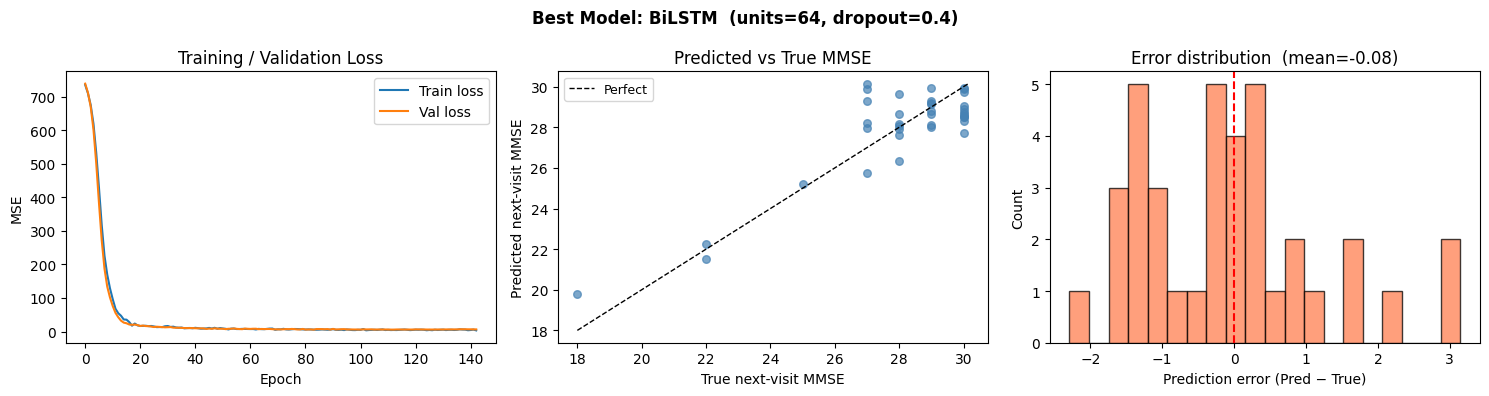

Saved: best_model_diagnostics.png
95th percentile of absolute errors: 2.42 MMSE points


In [ ]:
# =========================================================
# 15) PLOTS: learning curve, predicted vs true, error dist
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Best Model: {best_type}  (units={best_res["Units"]}, dropout={best_res["Dropout"]})',
             fontsize=12, fontweight='bold')

# Learning curve
ax = axes[0]
ax.plot(best_history.history['loss'],     label='Train loss')
ax.plot(best_history.history['val_loss'], label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Training / Validation Loss')
ax.legend()

# Predicted vs true
ax = axes[1]
ax.scatter(y_te, best_yhat, alpha=0.7, s=30, color='steelblue')
mn = float(min(y_te.min(), best_yhat.min()))
mx = float(max(y_te.max(), best_yhat.max()))
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='Perfect')
ax.set_xlabel('True next-visit MMSE')
ax.set_ylabel('Predicted next-visit MMSE')
ax.set_title('Predicted vs True MMSE')
ax.legend(fontsize=9)

# Error distribution
ax = axes[2]
errors = best_yhat - y_te
ax.hist(errors, bins=20, edgecolor='black', alpha=0.75, color='coral')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Prediction error (Pred − True)')
ax.set_ylabel('Count')
ax.set_title(f'Error distribution  (mean={errors.mean():.2f})')

plt.tight_layout()
plt.savefig('best_model_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: best_model_diagnostics.png')

abs_errors = np.abs(errors)
p95 = np.percentile(abs_errors, 95)
print(f"95th percentile of absolute errors: {p95:.2f} MMSE points")

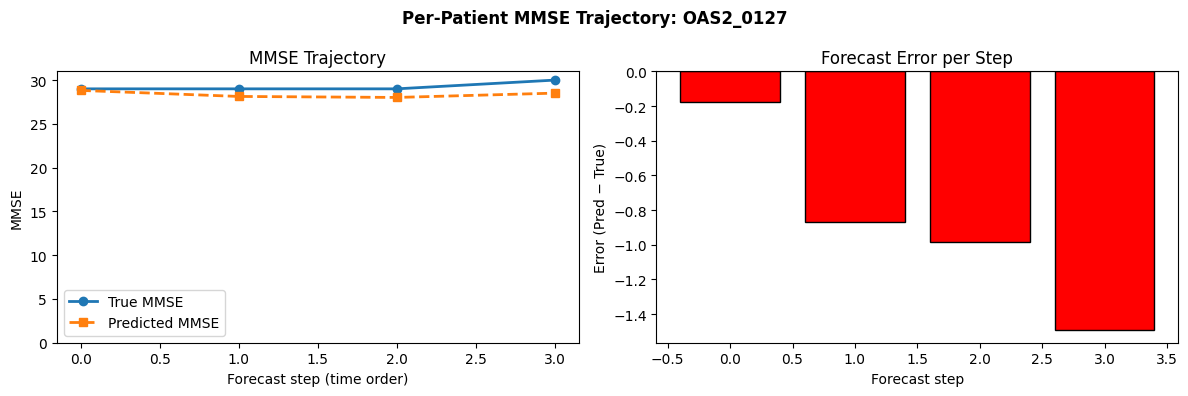

Subject OAS2_0127: 4 forecast points


In [ ]:
# =========================================================
# 16) PER-PATIENT TRAJECTORY VIEW (test set)
# Shows how the model tracks actual MMSE trajectory for a subject.
# =========================================================
unique_test_subjects = np.unique(sid_te)

# Pick a subject with the most forecast points for an informative plot
subj_counts = {s: (sid_te == s).sum() for s in unique_test_subjects}
chosen = max(subj_counts, key=lambda s: subj_counts[s])
idx = np.where(sid_te == chosen)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Per-Patient MMSE Trajectory: {chosen}', fontsize=12, fontweight='bold')

# Left: trajectory
ax = axes[0]
ax.plot(range(len(idx)), y_te[idx],         'o-', label='True MMSE',      linewidth=2)
ax.plot(range(len(idx)), best_yhat[idx],     's--', label='Predicted MMSE', linewidth=2)
ax.set_xlabel('Forecast step (time order)')
ax.set_ylabel('MMSE')
ax.set_title('MMSE Trajectory')
ax.legend()
ax.set_ylim([0, 31])

# Right: error at each step
ax = axes[1]
step_errors = best_yhat[idx] - y_te[idx]
colours = ['red' if e < 0 else 'steelblue' for e in step_errors]
ax.bar(range(len(idx)), step_errors, color=colours, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Forecast step')
ax.set_ylabel('Error (Pred − True)')
ax.set_title('Forecast Error per Step')

plt.tight_layout()
plt.savefig('patient_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Subject {chosen}: {len(idx)} forecast points')

## 13. Cross-Validation

To robustly assess performance given the small dataset size, we apply
**5-fold GroupKFold cross-validation** on the train+val pool.
GroupKFold ensures patient visits are never split across folds.

In [ ]:
# =========================================================
# 17) 5-FOLD GROUP-K-FOLD CROSS-VALIDATION
# =========================================================
print(f"Running 5-Fold GroupKFold CV for {best_type} (best config)...")

# Pool train + val for cross-validation
df_trainval_enc = pd.concat([df_train_enc, df_val_enc], ignore_index=True)
X_tv_v, y_tv, sid_tv = make_nextstep_examples_abs(df_trainval_enc)
max_len_cv = max([x.shape[0] for x in X_tv_v])
X_tv, m_tv = pad(X_tv_v, max_len_cv, n_feat)

gkf = GroupKFold(n_splits=5)
cv_results = []

best_units   = int(best_res['Units'])
best_dropout = float(best_res['Dropout'])
best_batch   = int(best_res['Batch'])

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_tv, y_tv, groups=sid_tv)):
    X_f_tr, y_f_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_f_va, y_f_va = X_tv[va_idx], y_tv[va_idx]
    m_f_tr, m_f_va = m_tv[tr_idx], m_tv[va_idx]

    # Fit scaler on this fold's training timesteps only
    fold_scaler = StandardScaler()
    fold_scaler.fit(X_f_tr[m_f_tr.astype(bool)].reshape(-1, n_feat))

    def fold_scale(X, mask, scl=fold_scaler):
        X_s = np.zeros_like(X)
        for i in range(len(X)):
            L = int(mask[i].sum())
            if L > 0:
                X_s[i, :L, :] = scl.transform(X[i, :L, :])
        return X_s

    X_f_tr_s = fold_scale(X_f_tr, m_f_tr)
    X_f_va_s = fold_scale(X_f_va, m_f_va)

    fold_model = build_model(best_type, units=best_units, dropout=best_dropout)
    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=30, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', patience=12, factor=0.5, min_lr=1e-5)
    ]
    fold_model.fit(X_f_tr_s, y_f_tr,
                   validation_data=(X_f_va_s, y_f_va),
                   epochs=300, batch_size=best_batch,
                   verbose=0, callbacks=cbs)

    yhat_fold = fold_model.predict(X_f_va_s, batch_size=128, verbose=0).reshape(-1)
    cv_results.append({
        'Fold':  fold + 1,
        'MAE':   round(float(mean_absolute_error(y_f_va, yhat_fold)), 4),
        'RMSE':  round(float(rmse(y_f_va, yhat_fold)), 4),
        'R2':    round(float(r2_score(y_f_va, yhat_fold)), 4),
    })
    print(f"  Fold {fold+1}: MAE={cv_results[-1]['MAE']:.4f}  "
          f"RMSE={cv_results[-1]['RMSE']:.4f}  R²={cv_results[-1]['R2']:.4f}")

cv_df = pd.DataFrame(cv_results)
print('\nCV Summary:')
print(cv_df.to_string(index=False))
print(f'\nMean  MAE = {cv_df.MAE.mean():.4f} ± {cv_df.MAE.std():.4f}')
print(f'Mean RMSE = {cv_df.RMSE.mean():.4f} ± {cv_df.RMSE.std():.4f}')
print(f'Mean  R²  = {cv_df.R2.mean():.4f}  ± {cv_df.R2.std():.4f}')

Running 5-Fold GroupKFold CV for BiLSTM (best config)...
  Fold 1: MAE=2.1026  RMSE=2.9590  R²=0.3504
  Fold 2: MAE=1.6412  RMSE=2.1208  R²=0.5871
  Fold 3: MAE=2.5639  RMSE=4.0158  R²=0.6143
  Fold 4: MAE=1.6747  RMSE=2.2749  R²=0.3633
  Fold 5: MAE=1.8450  RMSE=2.5697  R²=0.4339

CV Summary:
 Fold    MAE   RMSE     R2
    1 2.1026 2.9590 0.3504
    2 1.6412 2.1208 0.5871
    3 2.5639 4.0158 0.6143
    4 1.6747 2.2749 0.3633
    5 1.8450 2.5697 0.4339

Mean  MAE = 1.9655 ± 0.3812
Mean RMSE = 2.7880 ± 0.7571
Mean  R²  = 0.4698  ± 0.1240


## 14. Results Summary and Interpretation

In [ ]:
# =========================================================
# 18) COMPREHENSIVE RESULTS SUMMARY
# =========================================================
print('=' * 70)
print('COMP703 — Dementia Progression Forecasting: Complete Results')
print('=' * 70)

print(f'\nDataset  : OASIS-2 Longitudinal')
print(f'Subjects : {df[SUBJECT_COL].nunique()} | Visit records: {len(df)}')
print(f'Features : {n_feat} (incl. CDR, MMSE history, nWBV, Age, MR Delay, ...)')
print(f'Task     : Predict absolute MMSE at next visit (sequence regression)')

print('\n--- Test Set Performance (held-out subjects) ---')
rows = [
    ('Persistence',         yhat_persist),
    ('Training-Mean',       yhat_mean),
    ('Linear Regression',   yhat_lr),
]
for cell_name, yhat_ in [(k, best_by_type[k][3]) for k in ['RNN','LSTM','GRU','BiLSTM']]:
    rows.append((f'{cell_name} (tuned)', yhat_))
rows.append((f'{best_type} (best overall)', yhat_best))

print(f"{'Model':<30}  {'MAE':>6}  {'RMSE':>6}  {'R²':>7}")
print('-' * 60)
for name, yhat_ in rows:
    print(f"{name:<30}  {mean_absolute_error(y_te, yhat_):.4f}  "
          f"{rmse(y_te, yhat_):.4f}  {r2_score(y_te, yhat_):.4f}")

print(f'\n--- Cross-Validation ({best_type}, 5-fold GroupKFold) ---')
print(f'Mean MAE : {cv_df.MAE.mean():.4f} ± {cv_df.MAE.std():.4f}')
print(f'Mean RMSE: {cv_df.RMSE.mean():.4f} ± {cv_df.RMSE.std():.4f}')
print(f'Mean R²  : {cv_df.R2.mean():.4f} ± {cv_df.R2.std():.4f}')

print('\n--- Hyperparameter Sweep Summary ---')
print(f'Total configurations evaluated: {len(sweep)}')
print(best_df[['Model','Units','Dropout','Batch','MAE','RMSE','R2','BestValLoss']].to_string(index=False))

COMP703 — Dementia Progression Forecasting: Complete Results

Dataset  : OASIS-2 Longitudinal
Subjects : 150 | Visit records: 371
Features : 12 (incl. CDR, MMSE history, nWBV, Age, MR Delay, ...)
Task     : Predict absolute MMSE at next visit (sequence regression)

--- Test Set Performance (held-out subjects) ---
Model                              MAE    RMSE       R²
------------------------------------------------------------
Persistence                     0.9459  1.3656  0.7160
Training-Mean                   2.2310  2.7946  -0.1893
Linear Regression               1.2573  1.6446  0.5881
RNN (tuned)                     1.2667  1.6211  0.5998
LSTM (tuned)                    1.0985  1.4358  0.6861
GRU (tuned)                     1.2024  1.5381  0.6398
BiLSTM (tuned)                  0.9886  1.2736  0.7530
BiLSTM (best overall)           0.9886  1.2736  0.7530

--- Cross-Validation (BiLSTM, 5-fold GroupKFold) ---
Mean MAE : 1.9655 ± 0.3812
Mean RMSE: 2.7880 ± 0.7571
Mean R²  : 0.4698 ±

## 15. Save Results and Model

In [ ]:
# =========================================================
# 19) SAVE RESULTS AND BEST MODEL
# =========================================================
quick_df.to_csv('quick_model_comparison.csv', index=False)
sweep_df.to_csv('sweep_model_comparison.csv', index=False)
best_df.to_csv('best_per_type.csv', index=False)
cv_df.to_csv('cv_results.csv', index=False)

best_model.save('best_mmse_forecast_model.keras')

print('Saved files:')
print('  quick_model_comparison.csv   — quick 4-architecture comparison')
print('  sweep_model_comparison.csv   — full 108-configuration sweep')
print('  best_per_type.csv            — best config per architecture')
print('  cv_results.csv               — 5-fold cross-validation results')
print('  best_mmse_forecast_model.keras — best trained model weights')
print('  eda_oasis2.png               — EDA plots')
print('  best_model_diagnostics.png   — model evaluation plots')
print('  patient_trajectory.png       — per-patient trajectory plot')

Saved files:
  quick_model_comparison.csv   — quick 4-architecture comparison
  sweep_model_comparison.csv   — full 108-configuration sweep
  best_per_type.csv            — best config per architecture
  cv_results.csv               — 5-fold cross-validation results
  best_mmse_forecast_model.keras — best trained model weights
  eda_oasis2.png               — EDA plots
  best_model_diagnostics.png   — model evaluation plots
  patient_trajectory.png       — per-patient trajectory plot
